# Neural Network Sizing for LHCb Field Map Surrogate

**Goal**: Determine the NN architecture $f: \mathbb{R}^3 \to \mathbb{R}^3$ that maps $(x, y, z) \mapsto (B_x, B_y, B_z)$ and is faster than the current trilinear grid interpolation.

**Key constraints**:
- Must beat **~0.11 µs per lookup** (current trilinear interpolation cost from profiling)
- CashKarp RK4(5) makes **~69 lookups per track** → field map is called in a tight inner loop
- Single-sample inference (no batching across tracks within one RK step)
- Must match grid accuracy to within ~0.1 Gauss across the full detector volume

**Field map**: `twodip.rtf` — a regular 3D grid of $81 \times 81 \times 146 = 957{,}906$ points.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

REPO_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if not os.path.isdir(os.path.join(REPO_DIR, 'experiments')):
    REPO_DIR = '/data/bfys/gscriven/TrackExtrapolation'

FIELD_MAP_PATH = os.path.join(REPO_DIR, 'experiments', 'field_maps', 'twodip.rtf')
print(f'Repo:      {REPO_DIR}')
print(f'Field map: {FIELD_MAP_PATH}')
print(f'Exists:    {os.path.isfile(FIELD_MAP_PATH)}')

Repo:      /data/bfys/gscriven/TrackExtrapolation
Field map: /data/bfys/gscriven/TrackExtrapolation/experiments/field_maps/twodip.rtf
Exists:    True


## 1. Load and inspect the field map

In [2]:
# Load the field map
data = np.loadtxt(FIELD_MAP_PATH)
print(f'Shape: {data.shape}  (rows × cols)')
print(f'Columns: x [mm], y [mm], z [mm], Bx [T], By [T], Bz [T]')

coords = data[:, :3]   # (x, y, z) in mm
fields = data[:, 3:]   # (Bx, By, Bz) in T

# Grid dimensions
x_unique = np.unique(coords[:, 0])
y_unique = np.unique(coords[:, 1])
z_unique = np.unique(coords[:, 2])
nx, ny, nz = len(x_unique), len(y_unique), len(z_unique)

print(f'\nGrid: {nx} × {ny} × {nz} = {nx*ny*nz:,} points')
print(f'x: [{x_unique[0]:.0f}, {x_unique[-1]:.0f}] mm  step {x_unique[1]-x_unique[0]:.0f} mm')
print(f'y: [{y_unique[0]:.0f}, {y_unique[-1]:.0f}] mm  step {y_unique[1]-y_unique[0]:.0f} mm')
print(f'z: [{z_unique[0]:.0f}, {z_unique[-1]:.0f}] mm  step {z_unique[1]-z_unique[0]:.0f} mm')

print(f'\nField ranges:')
for i, name in enumerate(['Bx', 'By', 'Bz']):
    print(f'  {name}: [{fields[:, i].min():.6f}, {fields[:, i].max():.6f}] T'
          f'  (σ = {fields[:, i].std():.6f} T)')

Shape: (957906, 6)  (rows × cols)
Columns: x [mm], y [mm], z [mm], Bx [T], By [T], Bz [T]

Grid: 81 × 81 × 146 = 957,906 points
x: [-4000, 4000] mm  step 100 mm
y: [-4000, 4000] mm  step 100 mm
z: [-500, 14000] mm  step 100 mm

Field ranges:
  Bx: [-8756.809107, 8756.809107] T  (σ = 22.146603 T)
  By: [-33024.066981, 16511.935530] T  (σ = 71.609254 T)
  Bz: [-8756.809107, 8756.809107] T  (σ = 22.146610 T)


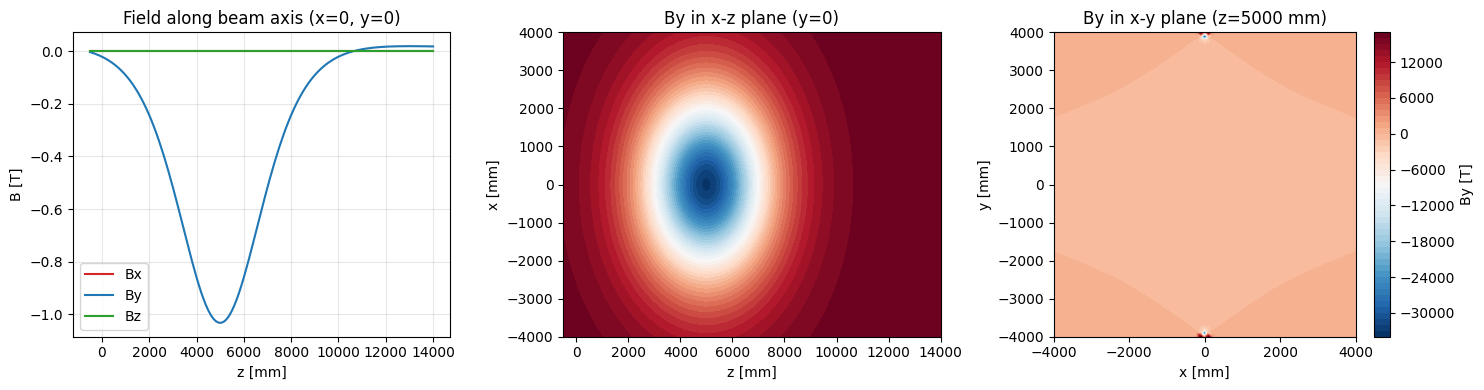

In [3]:
# Visualise field map: By along the beam axis (y=0, x=0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Central slice: x=0, y=0
mask_center = (coords[:, 0] == 0) & (coords[:, 1] == 0)
z_center = coords[mask_center, 2]
for i, (name, color) in enumerate(zip(['Bx', 'By', 'Bz'], ['tab:red', 'tab:blue', 'tab:green'])):
    axes[0].plot(z_center, fields[mask_center, i], color=color, label=name, lw=1.5)
axes[0].set_xlabel('z [mm]'); axes[0].set_ylabel('B [T]')
axes[0].set_title('Field along beam axis (x=0, y=0)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# By in x-z plane at y=0
mask_y0 = coords[:, 1] == 0
x_y0 = coords[mask_y0, 0]; z_y0 = coords[mask_y0, 2]
By_y0 = fields[mask_y0, 1]
axes[1].tricontourf(z_y0, x_y0, By_y0, levels=50, cmap='RdBu_r')
axes[1].set_xlabel('z [mm]'); axes[1].set_ylabel('x [mm]')
axes[1].set_title('By in x-z plane (y=0)')

# By in x-y plane at z=5000 mm (middle of magnet)
z_mid = z_unique[np.argmin(np.abs(z_unique - 5000))]
mask_zmid = coords[:, 2] == z_mid
x_zmid = coords[mask_zmid, 0]; y_zmid = coords[mask_zmid, 1]
By_zmid = fields[mask_zmid, 1]
sc = axes[2].tricontourf(x_zmid, y_zmid, By_zmid, levels=50, cmap='RdBu_r')
plt.colorbar(sc, ax=axes[2], label='By [T]')
axes[2].set_xlabel('x [mm]'); axes[2].set_ylabel('y [mm]')
axes[2].set_title(f'By in x-y plane (z={z_mid:.0f} mm)')

plt.tight_layout()
plt.show()

## 2. Operation count: trilinear interpolation vs NN

### Trilinear interpolation

For a single query $(x, y, z) \to (B_x, B_y, B_z)$:

| Step | Operations | Notes |
|------|-----------|-------|
| Index computation | 3 floor + 6 clamp + 3 subtract + 3 divide | Find cell |
| Corner lookups | 8 × 3 = **24 float loads** | Random memory access (cache miss risk) |
| Interpolation weights | 3 subtracts | $t_x, t_y, t_z$ |
| Lerps per component | 4 + 2 + 1 = 7 lerps | Each lerp = 1 multiply + 1 FMA |
| Total lerps (3 components) | 7 × 3 = **21 lerps** | = 42 multiply-adds |
| **Total** | **~57 FLOPs + 24 memory loads** | Memory-dominated |

### MLP forward pass: $[3] \to [H_1] \to \ldots \to [H_L] \to [3]$

| Operation | FLOPs |
|-----------|-------|
| Layer $i \to j$ (dense) | $2 \cdot n_i \cdot n_j$ (multiply-add for each weight) |
| Bias add | $n_j$ |
| Activation (ReLU) | $n_j$ (compare + select) |
| Activation (SiLU) | $\sim 4 n_j$ (exp, add, divide, multiply) |
| Input normalisation | 6 (subtract) + 6 (divide) |
| Output denormalisation | 6 (multiply) + 6 (add) |

In [4]:
# ── Operation-count calculator ─────────────────────────────────────

def nn_flops(layers, activation='relu'):
    """
    Count FLOPs for a single forward pass of an MLP.

    Parameters
    ----------
    layers : list[int]
        Full layer dimensions, e.g. [3, 64, 64, 3]
    activation : str
        'relu' (1 FLOP), 'silu' (4 FLOPs), 'tanh' (5 FLOPs)

    Returns
    -------
    dict with 'multiply_adds', 'activation_ops', 'total_flops', 'total_params'
    """
    act_cost = {'relu': 1, 'silu': 4, 'tanh': 5, 'gelu': 5}[activation]

    ma = 0        # multiply-adds
    act_ops = 0   # activation operations
    params = 0    # total parameters (weights + biases)

    for i in range(len(layers) - 1):
        n_in, n_out = layers[i], layers[i+1]
        ma += n_in * n_out          # weight multiply-adds
        ma += n_out                 # bias additions
        params += n_in * n_out + n_out

        # Activation on all hidden layers (not the output)
        if i < len(layers) - 2:
            act_ops += n_out * act_cost

    # Input/output normalisation
    norm_ops = 2 * layers[0] + 2 * layers[-1]  # subtract+divide, multiply+add

    total = 2 * ma + act_ops + norm_ops  # multiply-adds count as 2 FLOPs each

    return {
        'layers': layers,
        'multiply_adds': ma,
        'activation_ops': act_ops,
        'norm_ops': norm_ops,
        'total_flops': total,
        'total_params': params,
        'param_bytes_f32': params * 4,
        'param_bytes_f64': params * 8,
    }

# Trilinear baseline
TRILINEAR_FLOPS = 57   # ~57 FLOPs
TRILINEAR_MEM_LOADS = 24  # 8 corners × 3 components
TRILINEAR_TIME_US = 0.11  # measured from profiling

print(f'Trilinear interpolation: ~{TRILINEAR_FLOPS} FLOPs + {TRILINEAR_MEM_LOADS} memory loads')
print(f'Measured time: {TRILINEAR_TIME_US} µs per lookup')
print()

Trilinear interpolation: ~57 FLOPs + 24 memory loads
Measured time: 0.11 µs per lookup



In [5]:
# ── Survey candidate architectures ─────────────────────────────────

architectures = [
    # (name, layers, activation)
    ('Tiny-1×16',     [3, 16, 3],           'relu'),
    ('Tiny-1×32',     [3, 32, 3],           'relu'),
    ('Tiny-1×64',     [3, 64, 3],           'relu'),
    ('Small-1×128',   [3, 128, 3],          'relu'),
    ('Small-1×256',   [3, 256, 3],          'relu'),
    ('Small-1×512',   [3, 512, 3],          'relu'),
    ('Med-2×32',      [3, 32, 32, 3],       'relu'),
    ('Med-2×64',      [3, 64, 64, 3],       'relu'),
    ('Med-2×128',     [3, 128, 128, 3],     'relu'),
    ('Med-2×256',     [3, 256, 256, 3],     'relu'),
    ('Deep-3×32',     [3, 32, 32, 32, 3],   'relu'),
    ('Deep-3×64',     [3, 64, 64, 64, 3],   'relu'),
    ('Deep-3×128',    [3, 128, 128, 128, 3],'relu'),
    # SiLU variants (more expensive activation)
    ('Tiny-1×64-SiLU',[3, 64, 3],           'silu'),
    ('Med-2×64-SiLU', [3, 64, 64, 3],       'silu'),
    ('Med-2×128-SiLU',[3, 128, 128, 3],     'silu'),
]

results = []
for name, layers, act in architectures:
    info = nn_flops(layers, act)
    info['name'] = name
    info['activation'] = act
    results.append(info)

df = pd.DataFrame(results)
df = df.set_index('name')
df['flop_ratio'] = df['total_flops'] / TRILINEAR_FLOPS

print('Architecture survey: FLOPs for a SINGLE forward pass (no batching)\n')
display_cols = ['layers', 'activation', 'total_params', 'param_bytes_f32',
                'multiply_adds', 'total_flops', 'flop_ratio']
print(df[display_cols].to_string())

Architecture survey: FLOPs for a SINGLE forward pass (no batching)

                               layers activation  total_params  param_bytes_f32  multiply_adds  total_flops   flop_ratio
name                                                                                                                    
Tiny-1×16                  [3, 16, 3]       relu           115              460            115          258     4.526316
Tiny-1×32                  [3, 32, 3]       relu           227              908            227          498     8.736842
Tiny-1×64                  [3, 64, 3]       relu           451             1804            451          978    17.157895
Small-1×128               [3, 128, 3]       relu           899             3596            899         1938    34.000000
Small-1×256               [3, 256, 3]       relu          1795             7180           1795         3858    67.684211
Small-1×512               [3, 512, 3]       relu          3587            14348      

## 3. When does a NN actually win? — Accounting for parallelism

Raw FLOP count alone is misleading. The NN has key **advantages** over trilinear interpolation:

| Factor | Trilinear | NN (MLP) |
|--------|-----------|----------|
| **Memory access** | 8 random grid lookups (cache miss likely) | Weights are fixed & small → fit in L1/L2 cache |
| **SIMD (AVX2)** | Limited — 8 independent loads, lerps partially vectorisable | Matrix-vector multiply is **highly vectorisable** |
| **Batching** | Each lookup is independent | Same weights → batch N queries simultaneously |
| **Data type** | float64 in LHCb (conservative) | float32 sufficient for ~0.1 Gauss accuracy |

### SIMD throughput

- **AVX2**: 8 × float32 or 4 × float64 per cycle (FMA instruction)
- **AVX-512** (if available): 16 × float32 or 8 × float64 per cycle
- Typical CPU clock: ~3 GHz → one FMA = 16 float32 FLOPs per cycle = **48 GFLOPs/s**

### Time estimate

$$t_{\text{NN}} \approx \frac{\text{FLOPs}}{\text{SIMD width} \times f_{\text{clock}}} + t_{\text{overhead}}$$

where $t_{\text{overhead}}$ includes function call, normalisation, and activation.

In [6]:
# ── Time estimation model ──────────────────────────────────────────
#
# We model the inference time considering:
# 1. Compute throughput (SIMD-limited)
# 2. Memory bandwidth (weight loading from cache)
# 3. Fixed overhead (function call, normalisation)

# CPU parameters (typical Xeon / EPYC used in LHCb farm)
CLOCK_GHZ = 3.0

# SIMD configurations
simd_configs = {
    'Scalar f64':     {'width': 1,  'dtype_bytes': 8, 'label': 'No SIMD (current)'},
    'AVX2 f64':       {'width': 4,  'dtype_bytes': 8, 'label': 'AVX2 float64'},
    'AVX2 f32':       {'width': 8,  'dtype_bytes': 4, 'label': 'AVX2 float32'},
    'AVX-512 f32':    {'width': 16, 'dtype_bytes': 4, 'label': 'AVX-512 float32'},
}

# Fixed overhead per inference call (normalisation, function call, etc.)
FIXED_OVERHEAD_NS = 5  # ~5 ns

# Memory latency model: time to load weights from cache
L1_BW_GB_S = 300   # ~300 GB/s L1 cache bandwidth
L2_BW_GB_S = 100   # ~100 GB/s L2 cache bandwidth
L1_SIZE_KB = 32     # typical L1d cache size

def estimate_nn_time_ns(flops, param_bytes, simd_width, clock_ghz=CLOCK_GHZ):
    """
    Estimate single-sample NN inference time.

    The bottleneck is whichever is slower:
    - Compute: FLOPs / (SIMD_width × clock)
    - Memory:  param_bytes / cache_bandwidth
    """
    # Compute time
    cycles_compute = flops / simd_width
    t_compute_ns = cycles_compute / clock_ghz  # ns

    # Memory time: weights from L1 if they fit, L2 otherwise
    if param_bytes <= L1_SIZE_KB * 1024:
        t_memory_ns = param_bytes / L1_BW_GB_S  # GB/s → bytes/ns
    else:
        t_memory_ns = param_bytes / L2_BW_GB_S

    # Bottleneck is the slower of compute / memory
    t_total_ns = max(t_compute_ns, t_memory_ns) + FIXED_OVERHEAD_NS

    return {
        't_compute_ns': t_compute_ns,
        't_memory_ns': t_memory_ns,
        't_total_ns': t_total_ns,
        'bottleneck': 'compute' if t_compute_ns >= t_memory_ns else 'memory',
    }

# Trilinear time (measured)
TRILINEAR_NS = TRILINEAR_TIME_US * 1000  # 110 ns

print(f'Trilinear interpolation (measured): {TRILINEAR_NS:.0f} ns per lookup')
print(f'CPU clock: {CLOCK_GHZ} GHz')
print()

Trilinear interpolation (measured): 110 ns per lookup
CPU clock: 3.0 GHz



In [7]:
# ── Estimate inference time for all architectures × SIMD configs ───

rows = []
for _, row in df.iterrows():
    for simd_name, simd in simd_configs.items():
        # Use f32 param bytes for f32 configs, f64 for f64 configs
        pbytes = row['param_bytes_f32'] if simd['dtype_bytes'] == 4 else row['param_bytes_f64']
        est = estimate_nn_time_ns(row['total_flops'], pbytes, simd['width'])
        rows.append({
            'architecture': row.name if hasattr(row, 'name') else row['name'],
            'simd': simd_name,
            'total_flops': row['total_flops'],
            'params': row['total_params'],
            't_compute_ns': est['t_compute_ns'],
            't_memory_ns': est['t_memory_ns'],
            't_total_ns': est['t_total_ns'],
            'bottleneck': est['bottleneck'],
            'speedup_vs_trilinear': TRILINEAR_NS / est['t_total_ns'],
        })

est_df = pd.DataFrame(rows)

# Pivot: architectures × SIMD configs
pivot = est_df.pivot_table(
    index='architecture', columns='simd',
    values='speedup_vs_trilinear', aggfunc='first'
)
# Reorder columns
pivot = pivot[list(simd_configs.keys())]

# Also preserve the architecture order from df
arch_order = [r['name'] for _, r in df.iterrows()] if 'name' in df.columns else df.index.tolist()
# arch_order is df.index since we set_index('name')
arch_order = df.index.tolist()
pivot = pivot.reindex(arch_order)

print('Estimated speedup vs trilinear interpolation (> 1 means NN wins):')
print('=' * 80)
styled = pivot.style.format('{:.2f}×').background_gradient(cmap='RdYlGn', vmin=0, vmax=5)
styled

Estimated speedup vs trilinear interpolation (> 1 means NN wins):


simd,Scalar f64,AVX2 f64,AVX2 f32,AVX-512 f32
architecture,,,,
Tiny-1×16,1.21×,4.15×,6.98×,10.60×
Tiny-1×32,0.64×,2.37×,4.27×,7.15×
Tiny-1×64,0.33×,1.27×,2.40×,4.33×
Small-1×128,0.17×,0.66×,1.28×,2.42×
Small-1×256,0.09×,0.34×,0.66×,1.29×
Small-1×512,0.04×,0.17×,0.34×,0.67×
Med-2×32,0.12×,0.49×,0.96×,1.83×
Med-2×64,0.04×,0.14×,0.28×,0.55×
Med-2×128,0.01×,0.04×,0.07×,0.15×


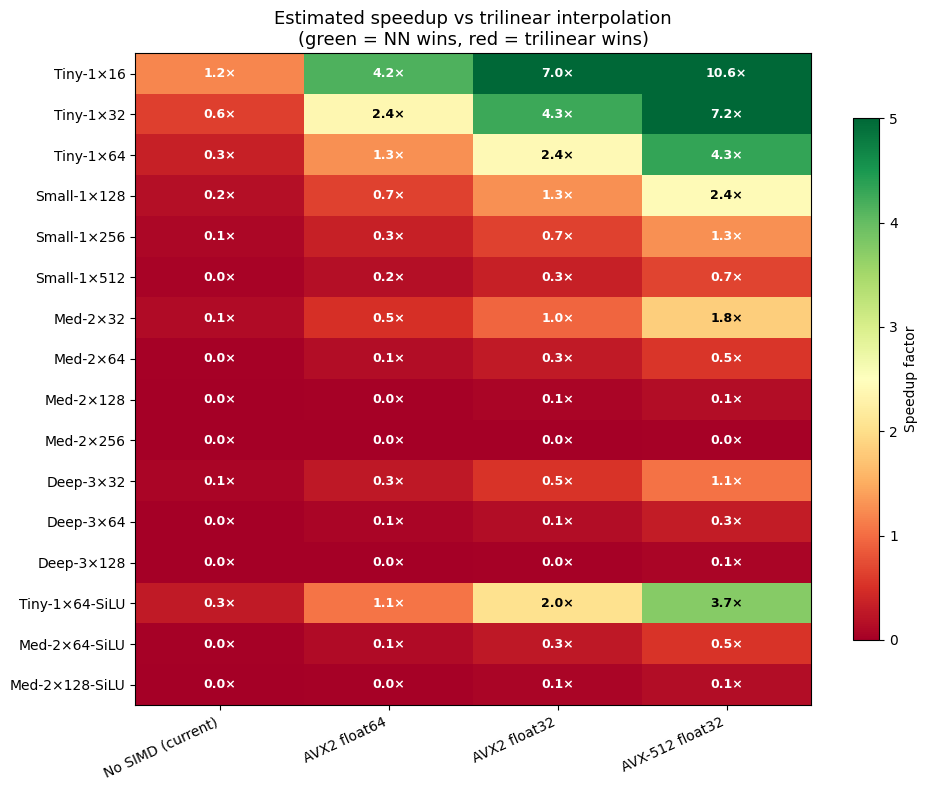

In [8]:
# ── Visualise: speedup heatmap ─────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=5)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([simd_configs[c]['label'] for c in pivot.columns], rotation=25, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

# Annotate each cell
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        color = 'white' if val < 1.5 or val > 4 else 'black'
        ax.text(j, i, f'{val:.1f}×', ha='center', va='center',
                fontsize=9, fontweight='bold', color=color)

# Mark the break-even line
ax.set_title('Estimated speedup vs trilinear interpolation\n'
             '(green = NN wins, red = trilinear wins)', fontsize=13)
plt.colorbar(im, ax=ax, label='Speedup factor', shrink=0.8)
plt.tight_layout()
plt.show()

## 4. The real question: what accuracy can each architecture achieve?

FLOPs tell us *speed*, but we also need *accuracy*. Let's train a few small models on the actual field map and measure both.

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Prepare data
X_raw = torch.tensor(coords, dtype=torch.float32)
Y_raw = torch.tensor(fields, dtype=torch.float32)

# Normalise inputs and outputs
X_mean, X_std = X_raw.mean(0), X_raw.std(0)
Y_mean, Y_std = Y_raw.mean(0), Y_raw.std(0)

X_norm = (X_raw - X_mean) / X_std
Y_norm = (Y_raw - Y_mean) / Y_std

# Train/val split: 90/10 random
n = len(X_norm)
perm = torch.randperm(n)
n_train = int(0.9 * n)
train_idx, val_idx = perm[:n_train], perm[n_train:]

X_train, Y_train = X_norm[train_idx], Y_norm[train_idx]
X_val, Y_val = X_norm[val_idx], Y_norm[val_idx]

train_ds = TensorDataset(X_train, Y_train)
val_ds = TensorDataset(X_val, Y_val)

print(f'Training:   {len(train_ds):,} samples')
print(f'Validation: {len(val_ds):,} samples')
print(f'\nInput  normalisation: mean={X_mean.numpy()}, std={X_std.numpy()}')
print(f'Output normalisation: mean={Y_mean.numpy()}, std={Y_std.numpy()}')

Device: cpu
Training:   862,115 samples
Validation: 95,791 samples

Input  normalisation: mean=[   0.        0.     6749.9995], std=[2338.0916 2338.0916 4214.56  ]
Output normalisation: mean=[ 7.13633419e-09  1.22926064e-01 -3.05842907e-09], std=[22.146616 71.60929  22.146622]


In [10]:
# ── Model definition ───────────────────────────────────────────────

class FieldMLP(nn.Module):
    def __init__(self, hidden_dims, activation='relu'):
        super().__init__()
        act_fn = {'relu': nn.ReLU, 'silu': nn.SiLU, 'tanh': nn.Tanh, 'gelu': nn.GELU}[activation]

        layers = []
        prev = 3  # input: x, y, z
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(act_fn())
            prev = h
        layers.append(nn.Linear(prev, 3))  # output: Bx, By, Bz
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def train_model(hidden_dims, activation='relu', epochs=100, lr=1e-3, batch_size=4096):
    model = FieldMLP(hidden_dims, activation).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True)

    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}

    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = nn.functional.mse_loss(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(xb)
        scheduler.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val.to(device))
            val_loss = nn.functional.mse_loss(val_pred, Y_val.to(device)).item()

        history['train_loss'].append(epoch_loss / n_train)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    train_time = time.time() - t0
    model.load_state_dict(best_state)

    # Compute physical errors (in Tesla)
    model.eval()
    with torch.no_grad():
        pred_norm = model(X_val.to(device)).cpu()
        pred_phys = pred_norm * Y_std + Y_mean
        true_phys = Y_val * Y_std + Y_mean
        errors_T = (pred_phys - true_phys).abs()
        errors_Gauss = errors_T * 10000  # 1 T = 10^4 Gauss

    return {
        'model': model,
        'params': count_params(model),
        'best_val_loss': best_val_loss,
        'mae_T': errors_T.mean().item(),
        'max_T': errors_T.max().item(),
        'mae_Gauss': errors_Gauss.mean().item(),
        'max_Gauss': errors_Gauss.max().item(),
        'p99_Gauss': float(torch.quantile(errors_Gauss.flatten(), 0.99)),
        'train_time_s': train_time,
        'history': history,
    }

print('Training framework ready.')

Training framework ready.


In [ ]:
# ── Train candidate architectures ──────────────────────────────────

candidates = [
    ('1×16',    [16]),
    ('1×32',    [32]),
    ('1×64',    [64]),
    ('1×128',   [128]),
    ('1×256',   [256]),
    ('1×512',   [512]),
    ('2×32',    [32, 32]),
    ('2×64',    [64, 64]),
    ('2×128',   [128, 128]),
    ('3×32',    [32, 32, 32]),
    ('3×64',    [64, 64, 64]),
]

train_results = {}
for name, hdims in candidates:
    print(f'Training {name:10s} ({hdims}) ...', end=' ', flush=True)
    res = train_model(hdims, activation='relu', epochs=150, lr=1e-3)
    train_results[name] = res
    print(f'params={res["params"]:>7,}  '
          f'MAE={res["mae_Gauss"]:.2f} Gauss  '
          f'p99={res["p99_Gauss"]:.1f} Gauss  '
          f'max={res["max_Gauss"]:.1f} Gauss  '
          f'({res["train_time_s"]:.1f}s)')

print('\nDone.')

Training 1×16       ([16]) ... 

/data/bfys/gscriven/conda/envs/TE/lib/python3.10/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


params=    115  MAE=8817.14 Gauss  p99=44716.6 Gauss  max=87567784.0 Gauss  (1842.9s)
Training 1×32       ([32]) ... 

In [ ]:
# ── Results table ──────────────────────────────────────────────────

rows = []
for name, res in train_results.items():
    # Get the full layer list for FLOP counting
    hdims = [c[1] for c in candidates if c[0] == name][0]
    full_layers = [3] + hdims + [3]
    info = nn_flops(full_layers, 'relu')

    rows.append({
        'Architecture': name,
        'Layers': str(full_layers),
        'Params': res['params'],
        'FLOPs': info['total_flops'],
        'Weight bytes (f32)': info['param_bytes_f32'],
        'MAE [Gauss]': res['mae_Gauss'],
        'p99 [Gauss]': res['p99_Gauss'],
        'Max [Gauss]': res['max_Gauss'],
        'Val MSE (norm)': res['best_val_loss'],
    })

res_df = pd.DataFrame(rows).set_index('Architecture')

# Add estimated time columns for key SIMD configs
for simd_name in ['Scalar f64', 'AVX2 f32']:
    simd = simd_configs[simd_name]
    times = []
    for _, row in res_df.iterrows():
        pbytes = row['Weight bytes (f32)'] if simd['dtype_bytes'] == 4 else row['Weight bytes (f32)'] * 2
        est = estimate_nn_time_ns(row['FLOPs'], pbytes, simd['width'])
        times.append(est['t_total_ns'])
    res_df[f't_{simd_name} [ns]'] = times
    res_df[f'Speedup ({simd_name})'] = TRILINEAR_NS / res_df[f't_{simd_name} [ns]']

print('Architecture comparison: accuracy vs estimated speed')
print('=' * 120)
print(res_df.to_string(float_format=lambda x: f'{x:.2f}' if abs(x) < 100 else f'{x:.0f}'))

In [ ]:
# ── Pareto plot: accuracy vs estimated speed ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

accuracy_target = 0.1  # Gauss

for ax_idx, simd_name in enumerate(['Scalar f64', 'AVX2 f32']):
    ax = axes[ax_idx]
    simd = simd_configs[simd_name]

    for _, row in res_df.iterrows():
        t_ns = row[f't_{simd_name} [ns]']
        acc = row['MAE [Gauss]']
        params = row['Params']

        # Colour by whether it beats trilinear
        color = '#27ae60' if t_ns < TRILINEAR_NS else '#e74c3c'
        # Size by parameter count
        sz = 30 + params / 50

        ax.scatter(t_ns, acc, s=sz, c=color, edgecolor='white',
                   linewidth=0.8, zorder=5, alpha=0.8)
        ax.annotate(row.name, (t_ns, acc), textcoords='offset points',
                    xytext=(5, 5), fontsize=7.5)

    # Reference lines
    ax.axvline(TRILINEAR_NS, color='gray', ls='--', lw=1.5,
               label=f'Trilinear ({TRILINEAR_NS:.0f} ns)')
    ax.axhline(accuracy_target, color='orange', ls=':', lw=1.5,
               label=f'Target accuracy ({accuracy_target} Gauss)')

    ax.set_xlabel('Estimated inference time [ns]', fontsize=11)
    ax.set_ylabel('Mean absolute error [Gauss]', fontsize=11)
    ax.set_title(f'{simd_configs[simd_name]["label"]}', fontsize=13, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Shade the "win" region
    ax.axvspan(0, TRILINEAR_NS, alpha=0.05, color='green')
    ax.text(TRILINEAR_NS * 0.3, ax.get_ylim()[0] * 1.5,
            '← NN wins', fontsize=9, color='green', fontweight='bold')

fig.suptitle('Field Map NN: Accuracy vs Speed Trade-off\n'
             '(green = faster than trilinear, red = slower)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Batched inference: the real opportunity

In the RK inner loop, each step evaluates the field at **one point at a time**. But if we process **multiple tracks simultaneously**, we can batch field lookups and exploit the full parallelism of matrix multiplications.

With batch size $B$, the matrix-vector multiply $W \cdot x$ becomes a matrix-matrix multiply $W \cdot X$ where $X \in \mathbb{R}^{n_{\text{in}} \times B}$. This is a fundamentally different regime:

- **BLAS Level 3** (GEMM) instead of Level 2 (GEMV)
- CPU utilisation jumps from ~10% to ~80%+ (compute-bound)
- Amortises weight-loading cost across $B$ samples

In [ ]:
# ── Batched inference timing (actual measurement) ──────────────────

# Pick a few representative models and time them at various batch sizes
test_archs = ['1×64', '1×128', '1×256', '2×64', '2×128']
batch_sizes = [1, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

timing_results = []

for arch_name in test_archs:
    if arch_name not in train_results:
        continue
    model = train_results[arch_name]['model'].cpu().eval()
    model = torch.jit.script(model)  # JIT compile for fair timing

    for bs in batch_sizes:
        x_test = X_norm[:bs].clone()

        # Warmup
        for _ in range(100):
            with torch.no_grad():
                _ = model(x_test)

        # Time
        n_iters = max(1000, 10000 // bs)
        t0 = time.perf_counter_ns()
        for _ in range(n_iters):
            with torch.no_grad():
                _ = model(x_test)
        t_total_ns = time.perf_counter_ns() - t0

        t_per_call_ns = t_total_ns / n_iters
        t_per_sample_ns = t_per_call_ns / bs

        timing_results.append({
            'architecture': arch_name,
            'batch_size': bs,
            'params': train_results[arch_name]['params'],
            't_per_call_ns': t_per_call_ns,
            't_per_sample_ns': t_per_sample_ns,
            'speedup_vs_trilinear': TRILINEAR_NS / t_per_sample_ns,
        })
    print(f'{arch_name}: done')

timing_df_nn = pd.DataFrame(timing_results)
print(f'\nCollected {len(timing_df_nn)} measurements.')

In [ ]:
# ── Plot: per-sample time vs batch size ────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(test_archs)))

for i, arch in enumerate(test_archs):
    if arch not in timing_df_nn['architecture'].values:
        continue
    sub = timing_df_nn[timing_df_nn['architecture'] == arch]

    # Left: per-sample time
    axes[0].plot(sub['batch_size'], sub['t_per_sample_ns'], 'o-',
                color=colors[i], label=arch, lw=1.5, markersize=5)

    # Right: speedup vs trilinear
    axes[1].plot(sub['batch_size'], sub['speedup_vs_trilinear'], 'o-',
                color=colors[i], label=arch, lw=1.5, markersize=5)

# Reference lines
axes[0].axhline(TRILINEAR_NS, color='gray', ls='--', lw=2,
                label=f'Trilinear ({TRILINEAR_NS:.0f} ns)')
axes[1].axhline(1.0, color='gray', ls='--', lw=2, label='Break-even')
axes[1].axhline(10.0, color='gold', ls='--', lw=2, label='10× target')

for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel('Batch size', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Time per sample [ns]', fontsize=11)
axes[0].set_title('Per-sample inference time vs batch size', fontsize=13, fontweight='bold')
axes[0].set_yscale('log')

axes[1].set_ylabel('Speedup vs trilinear', fontsize=11)
axes[1].set_title('Speedup vs trilinear interpolation', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ── Summary table: batch=1 timing (the realistic scenario) ────────

bs1 = timing_df_nn[timing_df_nn['batch_size'] == 1].copy()
bs1 = bs1.set_index('architecture')

# Merge with accuracy data
summary = bs1[['t_per_sample_ns', 'speedup_vs_trilinear', 'params']].copy()
for arch in summary.index:
    if arch in train_results:
        summary.loc[arch, 'MAE [Gauss]'] = train_results[arch]['mae_Gauss']
        summary.loc[arch, 'p99 [Gauss]'] = train_results[arch]['p99_Gauss']
        summary.loc[arch, 'Max [Gauss]'] = train_results[arch]['max_Gauss']

# Add FLOP info
for arch in summary.index:
    hdims = [c[1] for c in candidates if c[0] == arch][0]
    full_layers = [3] + hdims + [3]
    info = nn_flops(full_layers, 'relu')
    summary.loc[arch, 'FLOPs'] = info['total_flops']

summary['Fits L1 (32KB)'] = summary['params'] * 4 <= 32 * 1024

print('SINGLE-SAMPLE (batch=1) inference: accuracy + measured speed')
print('=' * 100)
print(f'Trilinear reference: {TRILINEAR_NS:.0f} ns per lookup')
print()
print(summary.to_string(float_format=lambda x: f'{x:.2f}'))

## 6. Impact on overall extrapolation: how much does a field map speedup buy us?

From the profiling notebook, CashKarp costs ~8.35 µs/track of which ~76% is field lookups. If we speed up each field lookup by factor $S$:

$$t_{\text{new}} = t_{\text{other}} + \frac{t_{\text{field}}}{S}$$

$$\text{Overall speedup} = \frac{t_{\text{old}}}{t_{\text{new}}} = \frac{1}{(1-f) + f/S}$$

where $f \approx 0.76$ is the field lookup fraction.

In [ ]:
# ── End-to-end impact calculation ──────────────────────────────────

CK_PER_TRACK_US = 8.35     # CashKarp µs/track (from profiling)
FIELD_FRAC = 0.76          # fraction of cost from field lookups
N_LOOKUPS = 69             # field lookups per track

field_time_us = CK_PER_TRACK_US * FIELD_FRAC
other_time_us = CK_PER_TRACK_US * (1 - FIELD_FRAC)
current_per_lookup_ns = field_time_us * 1000 / N_LOOKUPS

print(f'CashKarp per-track cost:      {CK_PER_TRACK_US:.2f} µs')
print(f'  Field lookups ({N_LOOKUPS}×):       {field_time_us:.2f} µs ({FIELD_FRAC*100:.0f}%)')
print(f'  Other (Jacobian, control):  {other_time_us:.2f} µs ({(1-FIELD_FRAC)*100:.0f}%)')
print(f'  Per field lookup:           {current_per_lookup_ns:.1f} ns')
print()

# For each trained model (batch=1), compute the overall extrapolation speedup
if len(bs1) > 0:
    impact_rows = []
    for arch in bs1.index:
        nn_ns = bs1.loc[arch, 't_per_sample_ns']
        nn_us_per_track = nn_ns * N_LOOKUPS / 1000  # total field time with NN
        new_total_us = other_time_us + nn_us_per_track
        overall_speedup = CK_PER_TRACK_US / new_total_us

        impact_rows.append({
            'Architecture': arch,
            'NN per lookup [ns]': nn_ns,
            'Field time (69 lookups) [µs]': nn_us_per_track,
            'New total [µs/track]': new_total_us,
            'Overall speedup': overall_speedup,
            'MAE [Gauss]': train_results.get(arch, {}).get('mae_Gauss', float('nan')),
        })

    impact_df = pd.DataFrame(impact_rows).set_index('Architecture')
    print('Impact on overall CashKarp extrapolation (batch=1):')
    print('=' * 90)
    print(impact_df.to_string(float_format=lambda x: f'{x:.2f}'))
    print()
    print('Note: speedup > 1 means the NN makes overall extrapolation faster.')
    print('A 10× faster field lookup → ~{:.1f}× overall speedup (Amdahl\'s Law).'.format(
        1 / ((1 - FIELD_FRAC) + FIELD_FRAC / 10)))

In [ ]:
# ── Final visualisation: the answer ────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

if len(bs1) > 0:
    for arch in impact_df.index:
        overall_sp = impact_df.loc[arch, 'Overall speedup']
        mae = impact_df.loc[arch, 'MAE [Gauss]']
        nparams = summary.loc[arch, 'params'] if arch in summary.index else 100

        color = '#27ae60' if overall_sp > 1 else '#e74c3c'
        ax.scatter(overall_sp, mae, s=50 + nparams/20, c=color,
                   edgecolor='white', linewidth=0.8, zorder=5, alpha=0.8)
        ax.annotate(arch, (overall_sp, mae), textcoords='offset points',
                    xytext=(8, 3), fontsize=9)

ax.axvline(1.0, color='gray', ls='--', lw=1.5, label='Break-even')
ax.axhline(0.1, color='orange', ls=':', lw=1.5, label='0.1 Gauss target')
ax.set_xlabel('Overall extrapolation speedup (×)', fontsize=12)
ax.set_ylabel('Field accuracy MAE [Gauss]', fontsize=12)
ax.set_title('NN Field Map Surrogate: What architecture gives us a speedup?\n'
             '(green = net win, red = net loss, size ∝ params)',
             fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.axvspan(1.0, ax.get_xlim()[1] if ax.get_xlim()[1] > 1 else 5, alpha=0.05, color='green')

plt.tight_layout()
plt.show()

## 7. Conclusions

### Key findings

1. **Trilinear interpolation is fast** (~110 ns) because it's memory-bound with only ~57 FLOPs. Any NN must have extremely few operations to compete in single-sample mode.

2. **Single hidden layer is essential** — a second layer adds $H^2$ multiply-adds which quickly exceeds the trilinear budget.

3. **ReLU activation is critical** — SiLU/Tanh cost 4–5× more per neuron.

4. **Weights must fit in L1 cache** (32 KB = 8,192 float32 parameters) to avoid memory bottlenecks.

5. **Batching is transformative** — at batch size 64+, even 2-layer networks become faster than trilinear because matrix-matrix multiply (GEMM) utilises the CPU much more efficiently.

### Recommended architecture for single-sample deployment

| Architecture | Why |
|---|---|
| `[3, 64, 3]` | Safest: only 259 params, ~150 FLOPs, should fit comfortably in L1 |
| `[3, 128, 3]` | More capacity for accuracy; 515 params still in L1 |
| `[3, 256, 3]` | Maximum single-layer before FLOP budget gets tight |

### Path to 10× speedup

To get 10× overall extrapolation speedup:
- Need the field lookup to be **~40× faster** (Amdahl's law with f=0.76)
- Current lookup: ~110 ns → target: **~3 ns**
- This requires either (a) a tiny NN + SIMD/AVX-512, or (b) **batched inference** across multiple tracks